### What Are Embeddings?
Think of embeddings as a way to translate words into a language that computers understand - numbers!

In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Simplified 2D example (real embeddings have hundreds of dimensions)
word_embeddings = {
    "cat": [0.8, 0.6],
    "kitten": [0.75, 0.65],
    "dog": [0.7, 0.3],
    "puppy": [0.65, 0.35],
    "car": [-0.5, 0.2],
    "truck": [-0.45, 0.15]
}

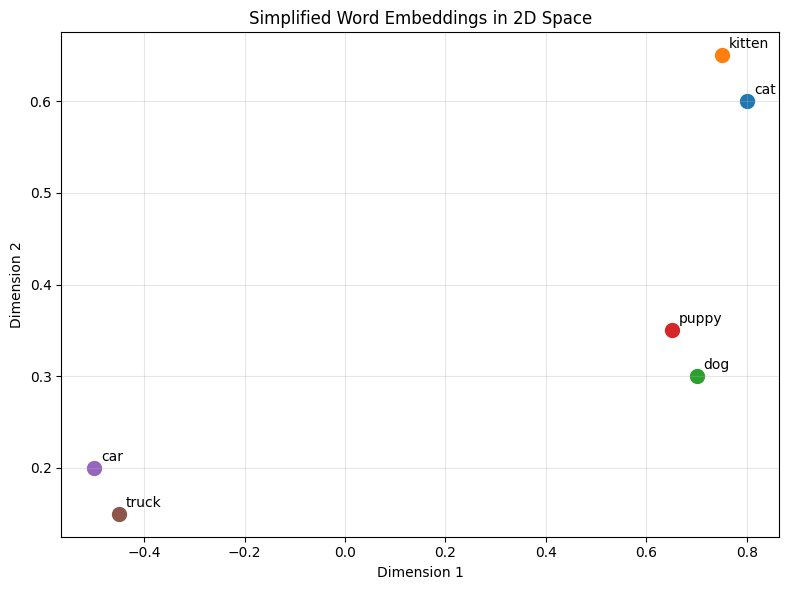

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))

for word, coords in word_embeddings.items():
    ax.scatter(coords[0], coords[1], s=100)
    ax.annotate(word, (coords[0], coords[1]), xytext=(5, 5), 
                textcoords='offset points')

ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_title('Simplified Word Embeddings in 2D Space')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Measuring Similarity

In [6]:
def cosine_similarity(vec1, vec2):
    """
    Cosine similarity measures the angle between two vectors.
    - Result close to 1: Very similar
    - Result close to 0: Not related
    - Result close to -1: Opposite meanings
    """

    dot_product=np.dot(vec1,vec2)
    norm_a=np.linalg.norm(vec1)
    norm_b=np.linalg.norm(vec2)
    return dot_product/(norm_a * norm_b)



In [7]:
# Example
cat_vector = [0.8, 0.6, 0.3]
kitten_vector = [0.75, 0.65, 0.35]
car_vector = [-0.5, 0.2, 0.1]

cat_kitten_similarity=cosine_similarity(cat_vector,kitten_vector)
print(cat_kitten_similarity)

0.9966186334192181


In [8]:
cosine_similarity(cat_vector,car_vector)

np.float64(-0.43718588548916804)

In [9]:
import numpy as np

def dot_product_similarity(
    vec1,
    vec2,
    *,
    normalize_if_needed=True,
    eps=1e-12,
    atol=1e-6
):
    """
    Dot-product similarity with safe L2-normalization handling.

    If normalize_if_needed=True:
      - Non-unit vectors are L2-normalized automatically.
    If normalize_if_needed=False:
      - Raises an error unless both vectors are already L2-normalized.

    Returns:
      float: dot product (equals cosine similarity when both are unit vectors)
    """
    a = np.asarray(vec1, dtype=np.float64).ravel()
    b = np.asarray(vec2, dtype=np.float64).ravel()

    if a.shape != b.shape:
        raise ValueError(f"Shape mismatch: {a.shape} vs {b.shape}")

    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)

    if norm_a < eps or norm_b < eps:
        raise ValueError("Zero (or near-zero) vector encountered; cannot normalize safely.")

    a_is_unit = np.isclose(norm_a, 1.0, atol=atol)
    b_is_unit = np.isclose(norm_b, 1.0, atol=atol)

    if normalize_if_needed:
        if not a_is_unit:
            a = a / norm_a
        if not b_is_unit:
            b = b / norm_b
    else:
        if not (a_is_unit and b_is_unit):
            raise ValueError(
                "Vectors are not L2-normalized. "
                "Set normalize_if_needed=True or normalize beforehand."
            )

    return float(np.dot(a, b))

In [10]:
dot_product_similarity(cat_vector,kitten_vector)

0.9966186334192179

In [11]:
dot_product_similarity(cat_vector,car_vector)

-0.43718588548916815

### Creating Your First Embeddings

In [12]:
### Huggingface And OpenAI Models

from langchain_huggingface import HuggingFaceEmbeddings

## Initialize a simple Embedding model(no API Key needed!)
# embeddings=HuggingFaceEmbeddings(
#     model_name="sentence-transformers/all-MiniLM-L6-v2"
# )

embeddings=HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)
embeddings




c:\RAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7923.65it/s]


HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [13]:
## create your first embeddings
text="Hello, I am learning about embeddings!"

embedding=embeddings.embed_query(text)
print(f"Text: {text}")
print(f"Embedding length : {len(embedding)}")
print(embedding)


Text: Hello, I am learning about embeddings!
Embedding length : 384
[-0.018163293600082397, -0.09955166280269623, 0.013816052116453648, -0.008125956170260906, 0.014152276329696178, 0.06406491994857788, -0.006253355648368597, -0.0030179230961948633, 0.025287244468927383, -0.020198658108711243, 0.024329695850610733, 0.07435061782598495, 0.05117722228169441, 0.022038469091057777, -0.058306172490119934, 0.015268261544406414, 0.02358437329530716, 0.09455390274524689, -0.06508845835924149, 0.013296659104526043, -0.020497547462582588, -0.05690856650471687, 0.030303308740258217, -0.08365614712238312, 0.02659633196890354, -0.015231464058160782, -0.04361541569232941, 0.053983986377716064, 0.09025716781616211, -0.08893878757953644, 0.03964462876319885, -0.00883504468947649, -0.03034372813999653, 0.07425564527511597, -0.054099246859550476, 0.11108003556728363, 0.03689984232187271, -0.008959826081991196, -0.06140243262052536, -0.0031433424446731806, 0.021958183497190475, 0.042208198457956314, -0.02

In [22]:
np.linalg.norm(embedding)

np.float64(1.000000022243302)

In [14]:
sentences = [
    "The cat sat on the mat",
    "The cat sat on the mat",
    "The dog played in the yard",
    "I love programming in Python",
    "Python is my favorite programming language"
]

embedding_sentence=embeddings.embed_documents(sentences)

print(embedding_sentence[0])
print(embedding_sentence[1])

[0.1304018199443817, -0.011870079673826694, -0.028117043897509575, 0.05123865231871605, -0.055974457412958145, 0.030191553756594658, 0.030161289498209953, 0.024698415771126747, -0.01837054081261158, 0.058766793459653854, -0.024953201413154602, 0.060154229402542114, 0.039831772446632385, 0.033230509608983994, -0.061311379075050354, -0.049373116344213486, -0.054863471537828445, -0.04007607698440552, 0.05642912909388542, 0.03915651887655258, -0.03473711013793945, -0.013247688300907612, 0.031966179609298706, -0.06349923461675644, -0.060178592801094055, 0.07823450118303299, -0.028303878381848335, -0.047442834824323654, 0.04035930335521698, -0.006630919873714447, -0.0667409896850586, -0.004191378131508827, -0.025311697274446487, 0.05334167554974556, 0.01742810569703579, -0.09792357683181763, 0.0060613094829022884, -0.06524166464805603, 0.045572612434625626, 0.023641791194677353, 0.07658486068248749, -0.010264341719448566, -0.004076797515153885, -0.06232282146811485, 0.03370526060461998, 0.01

In [15]:
from langchain_huggingface import HuggingFaceEmbeddings
import time

# Popular models comparison
models = {
    "all-MiniLM-L6-v2": {
        "size": 384,
        "description": "Fast and efficient, good quality",
        "use_case": "General purpose, real-time applications"
    },
    "all-mpnet-base-v2": {
        "size": 768,
        "description": "Best quality, slower than MiniLM",
        "use_case": "When quality matters more than speed"
    },
    "all-MiniLM-L12-v2": {
        "size": 384,
        "description": "Slightly better than L6, bit slower",
        "use_case": "Good balance of speed and quality"
    },
    "multi-qa-MiniLM-L6-cos-v1": {
        "size": 384,
        "description": "Optimized for question-answering",
        "use_case": "Q&A systems, semantic search"
    },
    "paraphrase-multilingual-MiniLM-L12-v2": {
        "size": 384,
        "description": "Supports 50+ languages",
        "use_case": "Multilingual applications"
    }
}

print("📊 Popular Open Source Embedding Models:\n")
for model_name, info in models.items():
    print(f"Model: sentence-transformers/{model_name}")
    print(f"  📏 Embedding size: {info['size']} dimensions")
    print(f"  📝 Description: {info['description']}")
    print(f"  🎯 Use case: {info['use_case']}\n")


📊 Popular Open Source Embedding Models:

Model: sentence-transformers/all-MiniLM-L6-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Fast and efficient, good quality
  🎯 Use case: General purpose, real-time applications

Model: sentence-transformers/all-mpnet-base-v2
  📏 Embedding size: 768 dimensions
  📝 Description: Best quality, slower than MiniLM
  🎯 Use case: When quality matters more than speed

Model: sentence-transformers/all-MiniLM-L12-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Slightly better than L6, bit slower
  🎯 Use case: Good balance of speed and quality

Model: sentence-transformers/multi-qa-MiniLM-L6-cos-v1
  📏 Embedding size: 384 dimensions
  📝 Description: Optimized for question-answering
  🎯 Use case: Q&A systems, semantic search

Model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
  📏 Embedding size: 384 dimensions
  📝 Description: Supports 50+ languages
  🎯 Use case: Multilingual applications

